# Gain Matrix Analysis

Initial training results has shown that the gain matrix (action space 3) produces the best results, with actual _convergence_ and _effort reduction_. The aim of this script is to analyse the progression of the model in learning the matrix parameters that produces the minimum position, velocity and effort.


In [75]:
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rl_corrective_gym.scripts.env_test_script import test_init

In [76]:
# initialise the directory parameters
result_dir: str = "../../../revamp-1-full"
folder: str = "SAC-mars-25_10_21_13-12-40"
config_file: str = "env_config.json"
eval_file: str = "10/data/eval.csv"

# initialise the dataframe of the eval csv
df = pd.read_csv(
    f"{result_dir}/{folder}/{eval_file}",
    on_bad_lines="skip",
    engine="python",
)

In [112]:
# initialise the env
env = test_init(file_name=f"{result_dir}/{folder}/{config_file}")
env.chosen_timestamp = df["timestep"].iloc[-1]

nom_imp: np.ndarray = env.nominal_imp[env.chosen_timestamp]
nom_traj: np.ndarray = copy.deepcopy(env.nominal_traj[env.chosen_timestamp])
nom_traj[3:6] -= nom_imp

env._init_logs()

In [78]:
# obtain the optimal gain matrix
stm = env._stm_pert()
A_opt = stm[:, 3:6]

In [ ]:
# PLOT 1: Gain Matrix parameters graphs

# create a matrix of all 18 parameters for the 1k eval episodes
policy_params: np.ndarray = np.empty((1000, 18))
for i in range(1000):
    policy_params[i] = np.fromstring(df["action"][i].strip("[]"), sep=" ")

opt_params: np.ndarray = np.reshape(A_opt, (18,))

# plotting of each parameter graph
for i in range(18):
    plt.figure(i)
    plt.plot(range(1000), policy_params[:, i], "r-", label="policy")
    plt.plot(range(1000), np.array([opt_params[i]] * 1000), "k-", label="optimal")

    plt.title(f"Gain Matrix Parameter {i}")
    plt.xlabel("Episode")
    plt.ylabel("Parameter Value")


plt.show()

In [ ]:
# PLOT 2: Convergence of the policy over time

# initialise the terminal fields
x_term: np.ndarray = copy.deepcopy(env.nominal_traj[-1])
x_term[3:6] -= env.nominal_imp[-1]

# initialise the datalogger
opt_pos_err: np.ndarray = np.array([])
opt_vel_err: np.ndarray = np.array([])
pol_pos_err: np.ndarray = np.array([])
pol_vel_err: np.ndarray = np.array([])

# for each noise scenario, compute the deviation by the optimal and policy
for i in range(1000):
    # compute optimal error
    env.noise = np.fromstring(df["noise"][i].strip("[]"), sep=" ")
    env.state = np.concatenate((nom_traj, nom_imp, nom_traj + env.noise))

    v_opt = env._pseudo_optimal_control(A_opt)
    opt_err = env._propagate(True, v_opt + nom_imp) - x_term

    opt_pos_err = np.append(opt_pos_err, np.linalg.norm(opt_err[0:3]))
    opt_vel_err = np.append(opt_vel_err, np.linalg.norm(opt_err[3:6]))

    # log the guid error
    pol_err = np.fromstring(df["gui_err"][i].strip("[]"), sep=" ")
    pol_pos_err = np.append(pol_pos_err, np.linalg.norm(pol_err[0:3]))
    pol_vel_err = np.append(pol_vel_err, np.linalg.norm(pol_err[3:6]))

plt.figure(1)
plt.title("Position Deviation")
plt.xlabel("Episode")
plt.ylabel("Deviation (km)")
plt.plot(range(1000), opt_pos_err, "k-", label="optimal")
plt.plot(range(1000), pol_pos_err, "r-", label="policy")

plt.figure(2)
plt.title("Velocity Deviation")
plt.ylabel("Deviation (km/s)")
plt.plot(range(1000), opt_vel_err, "k-", label="optimal")
plt.plot(range(1000), pol_vel_err, "r-", label="policy")

plt.legend()
plt.show()

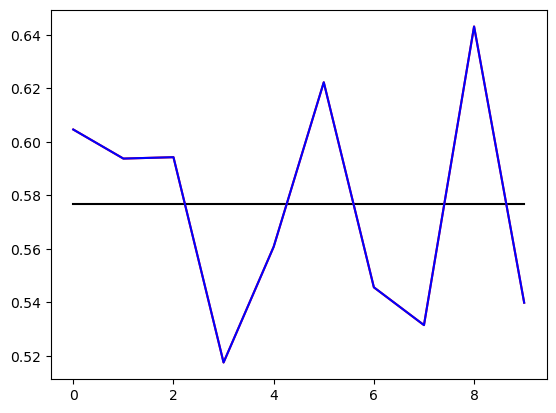

In [ ]:
# PLOT 3: Effort of control over time

# initialise datalogging
opt_control: np.ndarray = np.array([])
pol_control: np.ndarray = np.array([])

# get the control for each noise scenario
for i in range(1000):
    env.noise = np.fromstring(df["noise"][i].strip("[]"), sep=" ")
    env.state = np.concatenate((nom_traj, nom_imp, nom_traj + env.noise))
    A_pol = np.reshape(np.fromstring(df["action"][i].strip("[]"), sep=" "), (6, 3))

    # compute the control
    v_opt = env._pseudo_optimal_control(A_opt)
    v_pol = env._pseudo_optimal_control(A_pol)

    # log the total control
    opt_control = np.append(opt_control, np.linalg.norm(v_opt + nom_imp))
    pol_control = np.append(pol_control, np.linalg.norm(v_pol + nom_imp))

plt.figure(1)

plt.plot(range(1000), np.array([np.linalg.norm(nom_imp)] * 1000), "k-")
plt.plot(range(1000), opt_control, "r-")
plt.plot(range(1000), pol_control, "b-")

plt.show()